In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [64]:
data = pd.read_csv("retail_price.csv")
data.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [65]:
#Drop Leakage Columns
data = data.drop(columns=["total_price", "product_id", "month_year"])

In [66]:
#One-Hot Encoding Category
data = pd.get_dummies(
    data,
    columns=["product_category_name"],
    drop_first=True)

In [67]:
#target and features
y = data["qty"]

X = data.drop(columns=["qty"])

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [69]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.633640085270667
MAE: 6.078308823529412
RMSE: 9.965836790815734


In [70]:
# Take one product scenario from test set
sample = X_test.iloc[0].copy()

sample

freight_price                                   20.992778
unit_price                                     174.433333
product_name_lenght                                    35
product_description_lenght                            514
product_photos_qty                                      2
product_weight_g                                     4338
product_score                                         3.8
customers                                              91
weekday                                                22
weekend                                                 8
holiday                                                 4
month                                                  11
year                                                 2017
s                                               21.176471
volume                                               2856
comp_1                                              133.0
ps1                                                   4.2
fp1           

In [71]:
#Create Price Range
current_price = sample["unit_price"]

price_range = np.linspace(
    current_price * 0.5,
    current_price * 1.5,
    50
)

price_range[:5] 

array([ 87.21666665,  90.77653059,  94.33639454,  97.89625848,
       101.45612243])

In [72]:
##Revenue Simulation Loop
def find_optimal_price(model, sample_row):
    
    sample = sample_row.copy()
    
    current_price = sample["unit_price"]
    
    price_range = np.linspace(
        current_price * 0.5,
        current_price * 1.5,
        50
    )
    
    revenues = []
    
    for price in price_range:
        sample["unit_price"] = price
        sample_df = pd.DataFrame([sample])
        predicted_qty = model.predict(sample_df)[0]
        revenue = price * predicted_qty
        revenues.append(revenue)
    
    optimal_index = np.argmax(revenues)
    
    return {
        "current_price": current_price,
        "optimal_price": price_range[optimal_index],
        "max_revenue": revenues[optimal_index],
        "price_range": price_range,
        "revenues": revenues
    }

In [73]:
result = find_optimal_price(model, X_test.iloc[0])

print("Current Price:", result["current_price"])
print("Optimal Price:", result["optimal_price"])
print("Max Revenue:", result["max_revenue"])

Current Price: 174.4333333
Optimal Price: 261.64999995
Max Revenue: 4429.7344991535


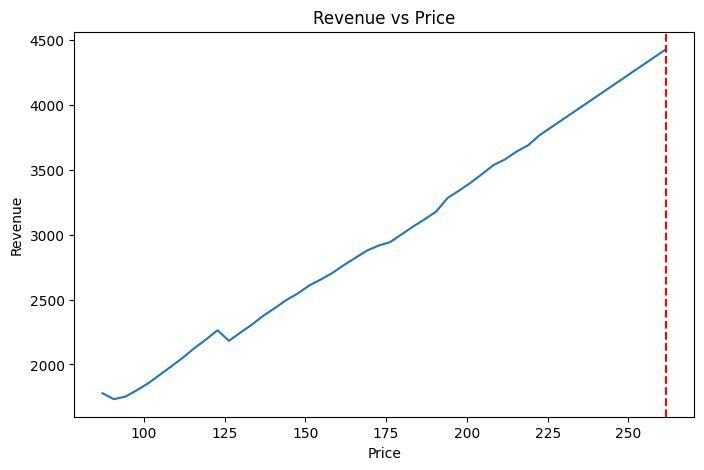

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(result["price_range"], result["revenues"])
plt.axvline(result["optimal_price"], color='red', linestyle='--')
plt.title("Revenue vs Price")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.show()

In [75]:
feature_columns = X.columns.tolist()

import joblib
joblib.dump(feature_columns, "models/feature_columns.pkl")

['models/feature_columns.pkl']